In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import csv
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

### TOP 10 parole per ogni tipologia di tossicità

#### 0 - tossicità generica

In [105]:
df_toxicity = pd.read_csv(
    "../datasets/dataset_0_toxicity.csv",
    sep=",",
    quoting=csv.QUOTE_MINIMAL,
    encoding="utf-8",
    engine="python"
)

In [106]:
df_toxicity['lemmatized']=df_toxicity['lemmatized'].fillna("")

In [107]:
vectorizer = TfidfVectorizer(max_features=20)  
X_tfidf = vectorizer.fit_transform(df_toxicity["lemmatized"])

feature_names = vectorizer.get_feature_names_out()

with open("./top20words_toxicity.txt", "w", encoding="utf-8") as f:
    for word in feature_names:
        f.write(word + "\n")

Top parole globali: [('get', 81.84311750868774), ('would', 56.32370161923539), ('go', 52.51104650650579), ('people', 51.819205775761844), ('one', 51.17554649809152), ('like', 48.05041612889104), ('good', 43.781548694985965), ('make', 43.12923760033175), ('use', 42.981914245856956), ('think', 39.58669219918276), ('even', 38.872850302431424), ('take', 38.14257416119304), ('know', 34.36186601826627), ('also', 32.41181959854605), ('say', 28.44540341414096), ('thing', 26.904615100325685), ('change', 22.669972003286333), ('could', 19.90667520367734), ('story', 13.34360602894748), ('spider', 6.765843727099995)]


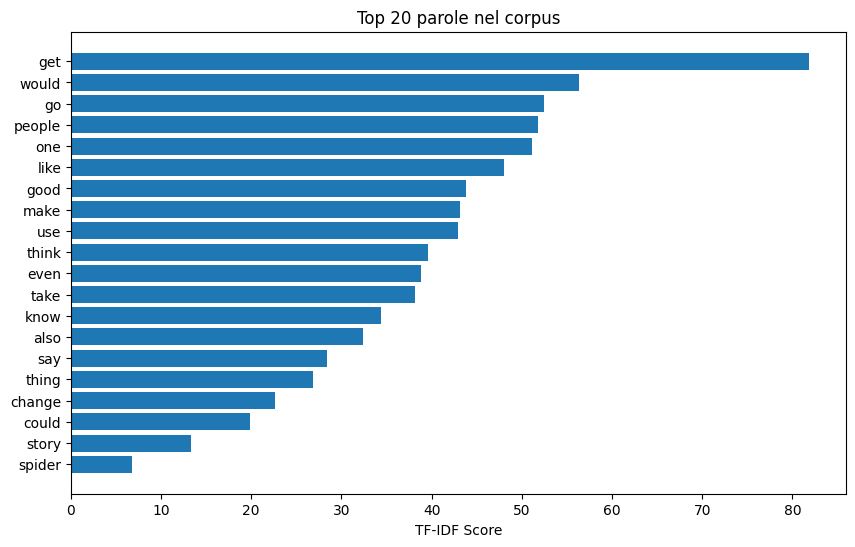

In [108]:
word_scores = np.asarray(X_tfidf.sum(axis=0)).ravel()
sorted_indices = word_scores.argsort()[::-1]

N = 20
top_words = [(feature_names[i], word_scores[i]) for i in sorted_indices[:N]]
print("Top parole globali:", top_words)

words, scores = zip(*top_words)
plt.figure(figsize=(10, 6))
plt.barh(words, scores)
plt.xlabel("TF-IDF Score")
plt.title(f"Top {N} parole nel corpus")
plt.gca().invert_yaxis()
plt.show()

#### 1 - racism

In [109]:
df_racism = pd.read_csv(
    "../datasets/dataset_1_racism.csv",
    sep=",",
    quoting=csv.QUOTE_MINIMAL,
    encoding="utf-8",
    engine="python"
)

In [110]:
df_racism['lemmatized']=df_racism['lemmatized'].fillna("")

In [111]:
vectorizer = TfidfVectorizer(max_features=20)  
X_tfidf = vectorizer.fit_transform(df_racism["lemmatized"])

feature_names = vectorizer.get_feature_names_out()

with open("./top20words_racism.txt", "w", encoding="utf-8") as f:
    for word in feature_names:
        f.write(word + "\n")

#### 2 - harassment

In [112]:
df_harassment = pd.read_csv(
    "../datasets/dataset_2_harassment.csv",
    sep=",",
    quoting=csv.QUOTE_MINIMAL,
    encoding="utf-8",
    engine="python"
)

In [113]:
df_harassment['lemmatized']=df_harassment['lemmatized'].fillna("")

In [114]:
vectorizer = TfidfVectorizer(max_features=20)  
X_tfidf = vectorizer.fit_transform(df_harassment["lemmatized"])

feature_names = vectorizer.get_feature_names_out()

with open("./top20words_harassment.txt", "w", encoding="utf-8") as f:
    for word in feature_names:
        f.write(word + "\n")

#### 3 - vulgarity

In [115]:
df_vulgarity = pd.read_csv(
    "../datasets/dataset_3_vulgarity.csv",
    sep=",",
    quoting=csv.QUOTE_MINIMAL,
    encoding="utf-8",
    engine="python"
)

In [116]:
df_vulgarity['lemmatized']=df_vulgarity['lemmatized'].fillna("")

In [117]:
vectorizer = TfidfVectorizer(max_features=20)  
X_tfidf = vectorizer.fit_transform(df_vulgarity["lemmatized"])

feature_names = vectorizer.get_feature_names_out()

with open("./top20words_vulgarity.txt", "w", encoding="utf-8") as f:
    for word in feature_names:
        f.write(word + "\n")

#### 4 - violence

In [118]:
df_violence = pd.read_csv(
    "../datasets/dataset_4_violence.csv",
    sep=",",
    quoting=csv.QUOTE_MINIMAL,
    encoding="utf-8",
    engine="python"
)

In [119]:
df_violence['lemmatized']=df_violence['lemmatized'].fillna("")

In [120]:
vectorizer = TfidfVectorizer(max_features=20)  
X_tfidf = vectorizer.fit_transform(df_violence["lemmatized"])

feature_names = vectorizer.get_feature_names_out()

with open("./top20words_violence.txt", "w", encoding="utf-8") as f:
    for word in feature_names:
        f.write(word + "\n")

## Funzione per richiamare controllo presenza/assenza di una parola 

In [127]:
paths = {
    "toxicity"      : "top20words_toxicity.txt",
    "violence"      : "top20words_violence.txt",
    "vulgarity"     : "top20words_vulgarity.txt",
    "racism"        : "top20words_racism.txt",
    "harassment"    : "top20words_harassment.txt"
}

def carica_topwords(paths, lowercase=True):
    out = {}
    for cat, path in paths.items():
        with open(path, "r", encoding="utf-8") as f:
            words = [line.strip() for line in f if line.strip()]
        out[cat] = [w.lower() for w in words] if lowercase else words
    return out

topwords_by_cat = carica_topwords(paths)

In [128]:
def presenza_top20words(category, lemmatized, topwords_by_cat, lowercase=True):

    tokset = set(t.lower() for t in lemmatized) if lowercase else set(lemmatized)

    out = {}
    for w in topwords_by_cat.get(category, []):
        word = w.lower() if lowercase else w
        colname = f"Top20_{word}"
        out[colname] = 1 if word in tokset else 0
    return out

## Calcolo 0/1 per ogni tossicità e la aggiungo al df

In [133]:
def add_top20_cols(df, cat, topwords_by_cat):
    df_top20 = (
        df['lemmatized']
          .apply(lambda toks: presenza_top20words(cat, toks or [], topwords_by_cat))
          .apply(pd.Series)
          .fillna(0)
          .astype('int8')
    )
    return df.join(df_top20)

#### applico la funzione per ciascuna categoria di tossicità

In [ ]:
df_toxicity = add_top20_cols(df_toxicity, "toxicity", topwords_by_cat)
df_racism = add_top20_cols(df_racism, "racism", topwords_by_cat)    
df_harassment = add_top20_cols(df_harassment, "harassment", topwords_by_cat)
df_vulgarity = add_top20_cols(df_vulgarity, "vulgarity", topwords_by_cat)
df_violence = add_top20_cols(df_violence, "violence", topwords_by_cat)

#### adesso mi salvo i nuovi datasets da utilizzare nel training del modello

In [136]:
df_toxicity.to_csv('../datasets/df_toxicity.csv', index=False)
df_racism.to_csv('../datasets/df_racism.csv', index=False)
df_harassment.to_csv('../datasets/df_harassment.csv', index=False)
df_vulgarity.to_csv('../datasets/df_vulgarity.csv', index=False)
df_violence.to_csv('../datasets/df_violence.csv', index=False)